In [1]:
import sys
import os
import random
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
from anndata import AnnData
import pathlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import skimage
import json
import seaborn as sns
import copy
from orderedset import OrderedSet
import DeepTalk_ST as dt
%matplotlib inline
%reload_ext autoreload
%autoreload 2

/root/miniconda3/envs/deeptalk_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Loading datasets**
Load public data available in Squidpy, from mouse brain cortex. 
Single cell data are stored in ```adata_sc```. Spatial data, in ```adata_st```..

In [ ]:
adata_st = sq.datasets.visium_fluo_adata_crop()
adata_st = adata_st[
    adata_st.obs.cluster.isin([f"Cortex_{i}" for i in np.arange(1, 5)])
].copy()
img = sq.datasets.visium_fluo_image_crop()
adata_sc = sq.datasets.sc_mouse_cortex()

100%|██████████| 65.5M/65.5M [00:06<00:00, 10.7MB/s]
100%|██████████| 303M/303M [00:24<00:00, 12.8MB/s] 
 41%|████      | 1.23G/3.03G [01:42<02:30, 12.8MB/s] 

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
sc.pl.spatial(
    adata_st, color="cluster", alpha=0.7, frameon=False, show=False, ax=axs[0]
)
sc.pl.umap(
    adata_sc, color="cell_subclass", size=10, frameon=False, show=False, ax=axs[1]
)
plt.tight_layout()

## **Pre-processing**

Quality control is applied to single-cell data, as the data has already been preprocessed, this step can be skipped. Different quality control standards should be applied to different data

In [ ]:
adata_sc.var["mt"] = adata_sc.var_names.str.startswith(r'^(mt-|MT-)')
sc.pp.calculate_qc_metrics(
    adata_sc, qc_vars=["mt"], inplace=True, percent_top=[20], log1p=True
)

fig, axs = plt.subplots(ncols = 2, figsize = (8,4))
sc.pl.scatter(adata_sc, x='total_counts', y='pct_counts_mt',ax = axs[0], show=False)
sc.pl.scatter(adata_sc, x='total_counts', y='n_genes_by_counts',ax = axs[1], show = False)

adata_sc = adata_sc[adata_sc.obs['pct_counts_mt'] < 20]  
adata_sc = adata_sc[adata_sc.obs['n_genes_by_counts'] < 16000]  
adata_sc = adata_sc[adata_sc.obs['total_counts'] < 55000]

#draw horizontal red lines indicating thresholds.
axs[0].hlines(y = 20, xmin = 0, xmax = max(adata_sc.obs['total_counts']), color = 'red', ls = 'dashed') 
fig.tight_layout()
plt.show()

In [ ]:
sc.pp.filter_cells(adata_sc, min_genes=200)
sc.pp.filter_genes(adata_sc, min_cells=3)
adata_sc_raw = copy.deepcopy(adata_sc)
sc.pp.normalize_total(adata_sc)
sc.pp.log1p(adata_sc)
adata_st_raw = copy.deepcopy(adata_st)
sc.pp.normalize_total(adata_st)
sc.pp.log1p(adata_st)

In order to deconvolve cells, **DeepTalk** needs to know how many cells are present in each voxel. This is achieved by segmenting the cells on the corresponding histology, which squidpy makes possible with two lines of code: ```squidpy.im.process``` applies smoothing as a pre-processing step. - ```squidpy.im.segment``` computes segmentation masks with watershed algorithm.

In [ ]:
sq.im.process(img=img, layer="image", method="smooth")

sq.im.segment(
    img=img,
    layer="image_smooth",
    method="watershed",
    channel=0
)

Let’s visualize the segmentation results for an inset

In [ ]:
inset_y = 1500
inset_x = 1700
inset_sy = 400
inset_sx = 500

fig, axs = plt.subplots(1, 3, figsize=(30, 10))
sc.pl.spatial(
    adata_st, color="cluster", alpha=0.7, frameon=False, show=False, ax=axs[0], title=""
)
axs[0].set_title("Clusters", fontdict={"fontsize": 20})
sf = adata_st.uns["spatial"]["V1_Adult_Mouse_Brain_Coronal_Section_2"]["scalefactors"][
    "tissue_hires_scalef"
]
rect = mpl.patches.Rectangle(
    (inset_y * sf, inset_x * sf),
    width=inset_sx * sf,
    height=inset_sy * sf,
    ec="yellow",
    lw=4,
    fill=False,
)
axs[0].add_patch(rect)

axs[0].axes.xaxis.label.set_visible(False)
axs[0].axes.yaxis.label.set_visible(False)

axs[1].imshow(
    img["image"][inset_y : inset_y + inset_sy, inset_x : inset_x + inset_sx, 0, 0]
    / 65536,
    interpolation="none",
)
axs[1].grid(False)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_title("DAPI", fontdict={"fontsize": 20})

crop = img["segmented_watershed"][
    inset_y : inset_y + inset_sy, inset_x : inset_x + inset_sx
].values.squeeze(-1)
crop = skimage.segmentation.relabel_sequential(crop)[0]
cmap = plt.cm.plasma
cmap.set_under(color="black")
axs[2].imshow(crop, interpolation="none", cmap=cmap, vmin=0.001)
axs[2].grid(False)
axs[2].set_xticks([])
axs[2].set_yticks([])
axs[2].set_title("Nucleous segmentation", fontdict={"fontsize": 20});

Comparison between DAPI and mask confirms the quality of the segmentation. We then need to extract some image features useful for the deconvolution task downstream. Specifically: - the number of unique segmentation objects (i.e. nuclei) under each spot. - the coordinates of the centroids of the segmentation object.

In [ ]:
# define image layer to use for segmentation
features_kwargs = {
    "segmentation": {
        "label_layer": "segmented_watershed",
        "props": ["label", "centroid"],
        "channels": [1, 2],
    }
}

sq.im.calculate_image_features(
    adata_st,
    img,
    layer="image",
    key_added="image_features",
    features_kwargs=features_kwargs,
    features="segmentation",
    mask_circle=True,
)


In [ ]:
adata_st.obsm['image_features']

We can visualize the total number of objects under each spot with scanpy.

In [ ]:
adata_st.obs["cell_count"] = adata_st.obsm["image_features"]["segmentation_label"]
sc.pl.spatial(adata_st, color=["cluster", "cell_count"], frameon=False)

For this case, we use 1291 marker genes as training genes.

In [13]:
sc.tl.rank_genes_groups(adata_sc, groupby="cell_subclass", use_raw=False)
markers_df = pd.DataFrame(adata_sc.uns["rank_genes_groups"]["names"]).iloc[0:100, :]
markers = list(np.unique(markers_df.melt().value.values))
len(markers)

1275

In [14]:
dt.pp_adatas(adata_sc, adata_st, genes=markers)

INFO:root:1158 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:14785 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


## **Deconvolution via DeepTalk**

In [15]:
ad_map = dt.map_cells_to_space(
    adata_sc=adata_sc,
    adata_sp=adata_st,
    learning_rate=0.0005,
    num_epochs=2000,
    #device='cpu', 
    device='cuda:0',
)

Start training
Epoch 100, Loss: -0.678,Score0: 0.678,Time: 0.431
Epoch 200, Loss: -0.683,Score0: 0.683,Time: 0.433
Epoch 300, Loss: -0.686,Score0: 0.686,Time: 0.438
Epoch 400, Loss: -0.689,Score0: 0.689,Time: 0.438
Epoch 500, Loss: -0.691,Score0: 0.691,Time: 0.439
Epoch 600, Loss: -0.695,Score0: 0.695,Time: 0.438
Epoch 700, Loss: -0.698,Score0: 0.698,Time: 0.440
Epoch 800, Loss: -0.700,Score0: 0.700,Time: 0.440
Epoch 900, Loss: -0.704,Score0: 0.704,Time: 0.440
Epoch 1000, Loss: -0.707,Score0: 0.707,Time: 0.441
Epoch 1100, Loss: -0.709,Score0: 0.709,Time: 0.442
Epoch 1200, Loss: -0.710,Score0: 0.710,Time: 0.441
Epoch 1300, Loss: -0.716,Score0: 0.716,Time: 0.440
Epoch 1400, Loss: -0.718,Score0: 0.718,Time: 0.441
Epoch 1500, Loss: -0.723,Score0: 0.723,Time: 0.441
Epoch 1600, Loss: -0.726,Score0: 0.726,Time: 0.442
Epoch 1700, Loss: -0.727,Score0: 0.727,Time: 0.441
Epoch 1800, Loss: -0.729,Score0: 0.729,Time: 0.442
Epoch 1900, Loss: -0.730,Score0: 0.730,Time: 0.441
Epoch 2000, Loss: -0.730,

In [ ]:
import torch
torch.cuda.empty_cache()

INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


<Figure size 640x480 with 0 Axes>

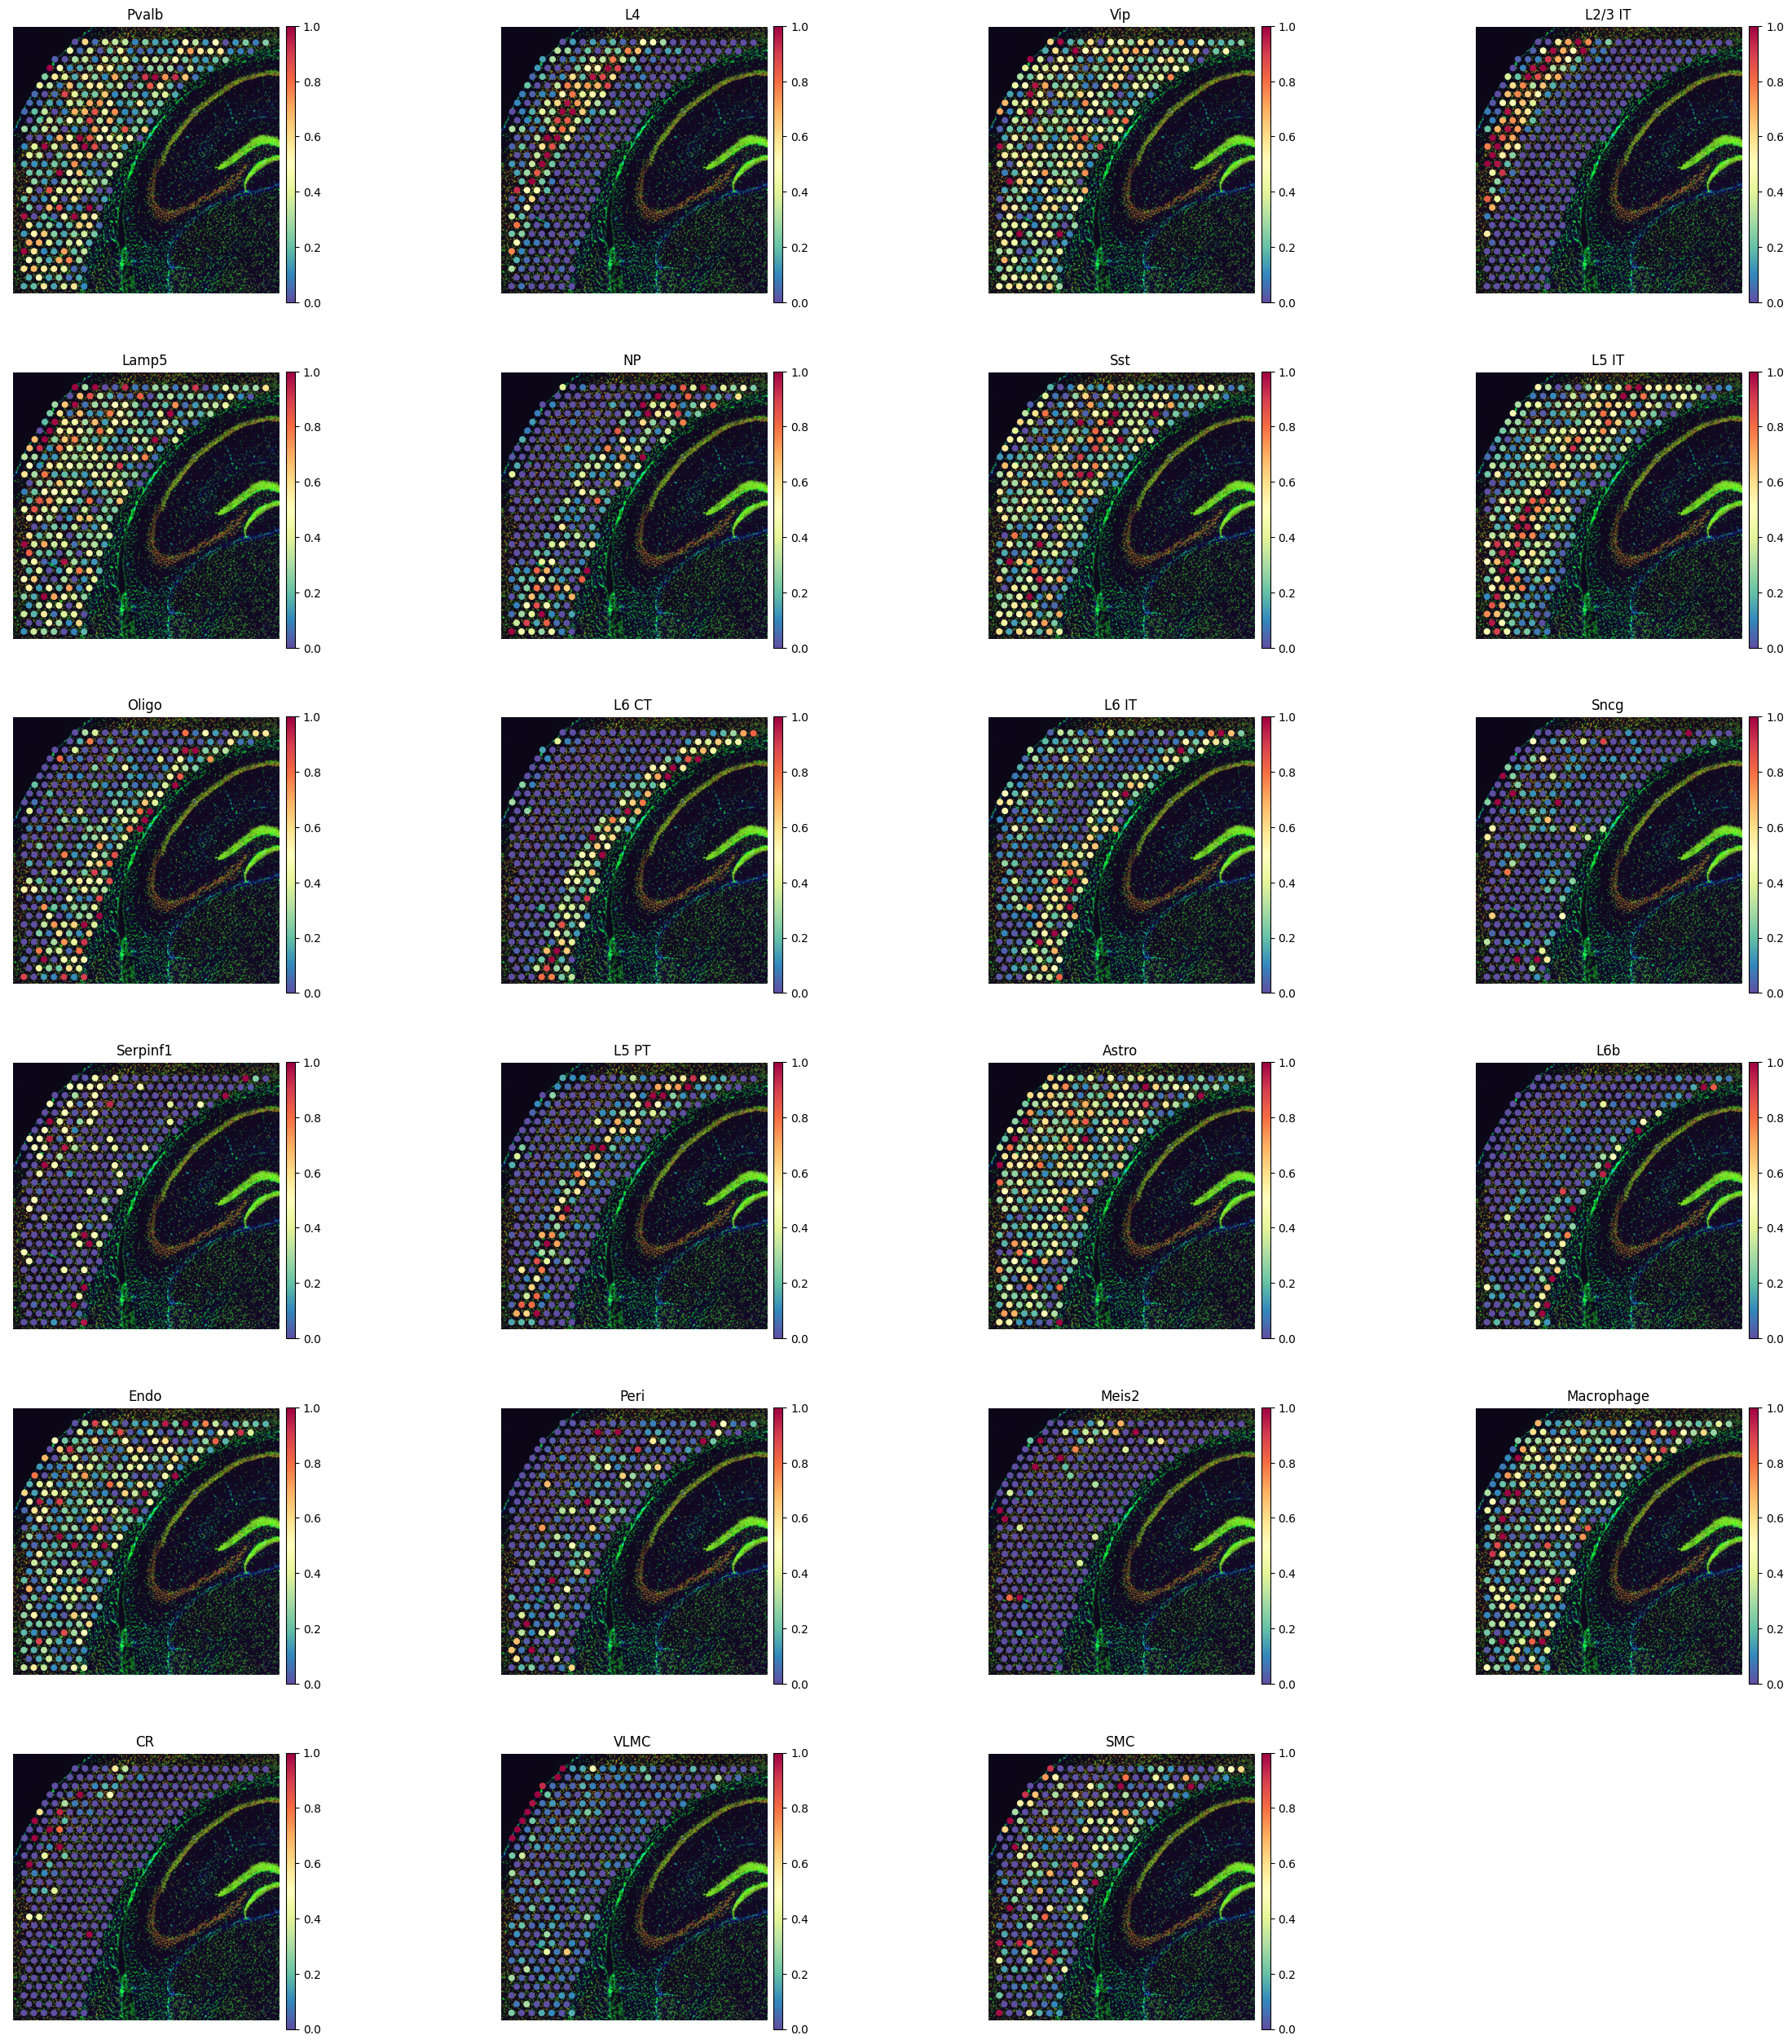

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
dt.project_cell_annotations(ad_map, adata_st, annotation="cell_subclass")
annotation_list = list(pd.unique(adata_sc.obs['cell_subclass']))
dt.plot_cell_annotation_sc1(adata_st, annotation_list,perc=0.02, cmap='Spectral_r', ncols=4,
                           scale_factor=adata_st.uns['spatial']['V1_Adult_Mouse_Brain_Coronal_Section_2']['scalefactors']['tissue_hires_scalef'])

In [ ]:
ad_ge = dt.project_genes(adata_map=ad_map, adata_sc=adata_sc)
ad_ge

In [ ]:
ad_ge.uns['spatial'] = adata_st.uns['spatial'].copy()
ad_ge.obsm['spatial'] = adata_st.obsm['spatial'].copy()

In [ ]:
df_all_genes = dt.compare_spatial_geneexp(ad_ge, adata_st, adata_sc)
df_all_genes

In [ ]:
dt.create_segment_cell_df(adata_st)
#adata_st.uns["tangram_cell_segmentation"]

In [ ]:
dt.count_cell_annotations(
    ad_map,
    adata_sc,
    adata_st,
    annotation="cell_subclass",
)
#adata_st.obsm["tangram_ct_count"]

In [ ]:
adata_segment = dt.deconvolve_cell_annotations(adata_st)
#adata_segment.obs

In [ ]:
mapping_colors = {
    "L6_CT": (0.19215686274509805, 0.5098039215686274, 0.7411764705882353),
    "L6_IT": (0.4196078431372549, 0.6823529411764706, 0.8392156862745098),
    "NP": (0.6196078431372549, 0.792156862745098, 0.8823529411764706),
    "L6b": "#0000c2ff",
    "L2/3_IT": "#a1ed7bff",
    "L5_IT": (0.19215686274509805, 0.6392156862745098, 0.32941176470588235),
    "L5_ET": (0.4549019607843137, 0.7686274509803922, 0.4627450980392157),
    "Oligo": (0.4588235294117647, 0.4196078431372549, 0.6941176470588235),
    "Vip": (0.6196078431372549, 0.6039215686274509, 0.7843137254901961),
    "Astro": "#ffdd55ff",
    "L6_CT": "#000000ff",
    "Pvalb": (0.38823529411764707, 0.38823529411764707, 0.38823529411764707),
    "Lamp5": (0.5882352941176471, 0.5882352941176471, 0.5882352941176471),
    "Sst": (0.7411764705882353, 0.7411764705882353, 0.7411764705882353),
    "CR": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
    "Sncg": (0.5176470588235295, 0.23529411764705882, 0.2235294117647059),
    "Peri": (0.6784313725490196, 0.28627450980392155, 0.2901960784313726),
    "VLMC": (0.8392156862745098, 0.3803921568627451, 0.4196078431372549),
    "Endo": (0.9058823529411765, 0.5882352941176471, 0.611764705882353),
    "Meis2": "#FFA500ff",
    "SMC": "#000000ff",
    "L6_PT": "#4682B4ff",
    "L5_PT": (0.19215686274509805, 0.6392156862745098, 0.32941176470588235),
    "L5_NP": "#6B8E23ff",
    "L4": "#d61f1dff",
    "Macrophage": "#2b2d2fff",
    "Serpinf1": "#000000ff",
}

In [84]:
newmeta = adata_segment.obs.copy()
newmeta.columns = newmeta.columns.str.replace(".", "-")
newmeta.insert(0, 'cell', newmeta.index)
newmeta["cell"] = newmeta["cell"].astype(int) + 1
newmeta["cell"] = "C" + newmeta["cell"].astype(str)
newmeta['spot'] = newmeta['centroids'].apply(lambda x: x.split('_')[0])
newmeta.rename(columns={'cluster': 'celltype'}, inplace=True)
newmeta["celltype"] = newmeta["celltype"].str.replace(" ", "_")
meta_data = newmeta[['cell','x','y','celltype']]

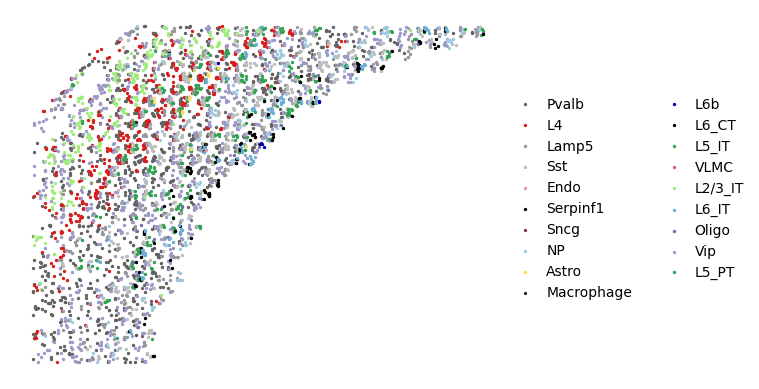

In [85]:
%matplotlib inline
import matplotlib.pyplot as plt
cluster = meta_data['celltype'].values
new_column_names = {'x': 'y', 'y': 'x'}
adata_segment.obs = adata_segment.obs.rename(columns=new_column_names)
dt.plot_cell_type_ST(adata_segment,mapping_colors,cluster)

## **Prediction of spatial CCC at the single-cell resolution.**
Train the data using subgraph-based GAT and generate a prediction model.

The training process may take some time.

The trained model can be used to predict intercellular communication mediated by other L-R interactions

In [175]:
Test_dir = '/home/DeepTalk/test'
isExists = os.path.exists(Test_dir)
if isExists:
    pass
else:
    os.makedirs(Test_dir)

In [87]:
Test_dir

'/home/DeepTalk/test/'

In [123]:
index1 = [word.capitalize() for word in adata_sc.var.index]
c_list = [f'C{i}' for i in range(1, adata_sc.X.shape[0]+1)]
ad_sc = pd.DataFrame(adata_sc.X.T,index=index1,columns=c_list)

index1 = [word.capitalize() for word in ad_ge.var.index]
c_list = [word.capitalize() for word in ad_ge.obs.index]
ad_ge_new = pd.DataFrame(ad_ge.X.T,index=index1,columns=c_list)
st_obs = adata_segment.obs.copy()
sc_obs = adata_sc.obs.copy()

In [124]:
stnewdata = dt.New_ST_data_pre(ad_sc, ad_ge_new, st_obs, sc_obs, outdir = Test_dir)

In [164]:
ad_sc

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C21688,C21689,C21690,C21691,C21692,C21693,C21694,C21695,C21696,C21697
0610005c13rik,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.690448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0610006l08rik,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0610007p14rik,0.733929,0.688069,0.707650,0.763792,0.824592,0.000000,0.000000,0.848170,0.654787,0.703890,...,0.743621,0.854912,0.708486,0.758446,0.686553,0.762341,0.657074,0.744034,0.609005,0.706241
0610009b22rik,0.765146,0.755940,0.688681,0.687946,0.815247,0.670191,0.801111,0.850696,0.617341,0.783182,...,0.716332,0.841946,0.732802,0.743997,0.690067,0.762628,0.697671,0.747108,0.662250,0.697369
0610009e02rik,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.582782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zzef1,0.779980,0.000000,0.000000,0.750748,0.759191,0.662652,0.000000,0.000000,0.622956,0.715407,...,0.000000,0.825271,0.667766,0.714284,0.642071,0.000000,0.441970,0.723901,0.598363,0.582782
Zzz3,0.521031,0.752956,0.000000,0.512997,0.818561,0.628015,0.701832,0.825667,0.645140,0.000000,...,0.000000,0.756622,0.533238,0.000000,0.447008,0.000000,0.674325,0.000000,0.526411,0.000000
A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
L7rn6,0.748078,0.755369,0.741882,0.735596,0.819167,0.626167,0.838952,0.825033,0.655575,0.756932,...,0.751672,0.859047,0.722598,0.760814,0.674207,0.754111,0.708150,0.743779,0.669537,0.682234


In [125]:
pathways = Test_dir + "/pathways.csv"
lrpairs = Test_dir + "/lrpairs_new.csv"
st_data = stnewdata
species = "Mouse"

In [138]:
stnewdata.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C5066,C5067,C5068,C5069,C5070,C5071,C5072,C5073,C5074,C5075
Abcc5,0.640188,0.661782,0.701838,0.639973,0.671910,0.817604,0.482497,0.809340,0.843150,0.000000,...,0.718568,0.712539,0.700232,0.766935,0.650911,0.643055,0.744982,0.617555,0.675568,0.656273
Abhd6,0.672339,0.661902,0.751606,0.664676,0.664909,0.814523,0.732439,0.000000,0.000000,0.000000,...,0.719513,0.745943,0.739951,0.812871,0.677174,0.598764,0.659527,0.554845,0.672541,0.673903
Abr,0.655383,0.680216,0.762014,0.668246,0.673196,0.822174,0.728161,0.000000,0.850355,0.857274,...,0.724086,0.767080,0.740757,0.793923,0.670048,0.682866,0.714592,0.613471,0.667325,0.664975
Acaa1a,0.622063,0.612116,0.697308,0.591747,0.656488,0.790461,0.720254,0.000000,0.776001,0.810857,...,0.699699,0.713137,0.727849,0.805005,0.680239,0.660508,0.376834,0.586398,0.676002,0.639525
Acat1,0.672107,0.685531,0.765002,0.678243,0.659199,0.808025,0.772826,0.795294,0.860966,0.854790,...,0.743195,0.745134,0.680407,0.835151,0.688663,0.682015,0.744010,0.629316,0.705015,0.678120


In [168]:
st_data.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C5066,C5067,C5068,C5069,C5070,C5071,C5072,C5073,C5074,C5075
Abcc5,0.640188,0.661782,0.701838,0.639973,0.671910,0.817604,0.482497,0.809340,0.843150,0.000000,...,0.718568,0.712539,0.700232,0.766935,0.650911,0.643055,0.744982,0.617555,0.675568,0.656273
Abhd6,0.672339,0.661902,0.751606,0.664676,0.664909,0.814523,0.732439,0.000000,0.000000,0.000000,...,0.719513,0.745943,0.739951,0.812871,0.677174,0.598764,0.659527,0.554845,0.672541,0.673903
Abr,0.655383,0.680216,0.762014,0.668246,0.673196,0.822174,0.728161,0.000000,0.850355,0.857274,...,0.724086,0.767080,0.740757,0.793923,0.670048,0.682866,0.714592,0.613471,0.667325,0.664975
Acaa1a,0.622063,0.612116,0.697308,0.591747,0.656488,0.790461,0.720254,0.000000,0.776001,0.810857,...,0.699699,0.713137,0.727849,0.805005,0.680239,0.660508,0.376834,0.586398,0.676002,0.639525
Acat1,0.672107,0.685531,0.765002,0.678243,0.659199,0.808025,0.772826,0.795294,0.860966,0.854790,...,0.743195,0.745134,0.680407,0.835151,0.688663,0.682015,0.744010,0.629316,0.705015,0.678120


In [134]:
lrpairs_pre['receptor'].isin(st_data.index)

0    True
Name: receptor, dtype: bool

In [135]:
lrpairs_pre['ligand'].isin(st_data.index)

0    False
Name: ligand, dtype: bool

In [170]:
search_terms = ["Fzd", "Se"]
matching_genes = st_data.index[st_data.index.str.contains("|".join(search_terms), case=False, na=False)]
print(matching_genes)


Index(['Fzd3', 'Psen1', 'Sec13', 'Sec23a', 'Sec24c', 'Senp5', 'Serpinb6a',
       'Sesn1', 'Set', 'Setd3', 'Setd7'],
      dtype='object')


In [146]:
search_term = "vegf"  # 你要搜索的關鍵字
matching_genes = st_data.index[st_data.index.str.contains(search_term, case=False, na=False)]
print(matching_genes)


Index(['Vegfa', 'Vegfb'], dtype='object')


**Generate training data.**

In [96]:
lrpairs_train = {
    'ligand': ['Mif'],
    'receptor': ['Epha5'],
    'species': ['Mouse']
}

lrpairs_train = pd.DataFrame(lrpairs_train)
lrpairs_train

,ligand,receptor,species
0,Mif,Epha5,Mouse


In [53]:
!apt install unrar -y


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  unrar
0 upgraded, 1 newly installed, 0 to remove and 24 not upgraded.
Need to get 145 kB of archives.
After this operation, 339 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/multiverse amd64 unrar amd64 1:6.1.5-1 [145 kB]
Fetched 145 kB in 1s (270 kB/s)
debconf: delaying package configuration, since apt-utils is not installed

78Selecting previously unselected package unrar.
(Reading database ... 44879 files and directories currently installed.)
Preparing to unpack .../unrar_1%3a6.1.5-1_amd64.deb ...
7Progress: [  0%] [..........................................................] 87Progress: [ 20%] [###########...............................................] 8Unpacking unrar (1:6.1.5-1) ...
7Progress: [ 40%] [#######################...................................] 8Setting up unrar (1:6.1.5-1)

In [62]:
!unrar x /home/DeepTalk/test/pathways.rar -y


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /home/DeepTalk/test/pathways.rar

Extracting  pathways.csv                                               100  OK 
All OK


In [33]:
!ls /home/DeepTalk/test/

Plot		 lrpairs_new.csv  pathways.rar	spot
df_pathways.csv  pathways.csv	  single-cell


In [48]:
dt.File_Train(st_data, pathways, lrpairs_train, meta_data, species, LR_train = 'Mif_Epha5',
              outdir =  Test_dir)

In [53]:
dt.data_for_train(st_data, data_dir = Test_dir +'/data/', 
	LR_train = 'Mif_Epha5')

**The process will take a long time, but we provide pre-trained models, so you can choose to skip this step.**

In [ ]:
dt.Train(data_name = 'Mif_Epha5', data_path = Test_dir + '/data/',
    outdir = Test_dir + '/data/Mif_Epha5/output',
    pretrained_embeddings = Test_dir + '/data/Mif_Epha5/data_pca.emd',
    n_epochs = 50,ft_n_epochs=10)

**Generate prediction data for Sema3c-Fzd3 pair.**

> Sema3c is not found , change to Sec23a by random choice. (Charles Chuang)

In [171]:
lrpairs_pre = {
    'ligand': ['Sec23a'],
    'receptor': ['Fzd3'],
    'species': ['Mouse']
}

lrpairs_pre = pd.DataFrame(lrpairs_pre)
lrpairs_pre

#Rims1 - Slc17a7
#Sema3c_Fzd3

,ligand,receptor,species
0,Sec23a,Fzd3,Mouse


In [172]:
dt.File_Pre(st_data, pathways, lrpairs_pre, meta_data, species, LR_Pre = 'Sec23a_Fzd3',
              outdir =  Test_dir)

In [173]:
dt.data_for_pre(st_data, data_dir = Test_dir +'/data/', LR_pre = 'Sec23a_Fzd3')

**Predicting cell-cell communication mediated by ```Sema3c_Fzd3```.**

> Test_dir + '/Mif_Epha5.model' changed to Test_dir + '/spot/Mif_Epha5.model'

> data_pca_test.emd changed to data_pca_pre.emd

In [178]:
dt.run_predict(data_name='Sec23a_Fzd3',data_path = Test_dir +'/data/',
    outdir = Test_dir +'/data/Sec23a_Fzd3/output',
    pretrained_embeddings = Test_dir +'/data/Sec23a_Fzd3/data_pca_pre.emd',
    model_path = Test_dir+'/data/Mif_Epha5/output/finetune/results',best_id = 2, 
    is_trained = True, model_name = Test_dir + '/spot/Mif_Epha5.model'
    )

DataSet Stats :
Number of Nodes 4968
Number of Edges 58245
Number of Node types 1
Number of relations 1
check torch.Size([4968, 128]) 4869
node2vec tensor torch.Size([4968, 128])
4 4 Linear(in_features=512, out_features=512, bias=True)
Begin Predicting
Done


## **Visualize of the spatial CCC**

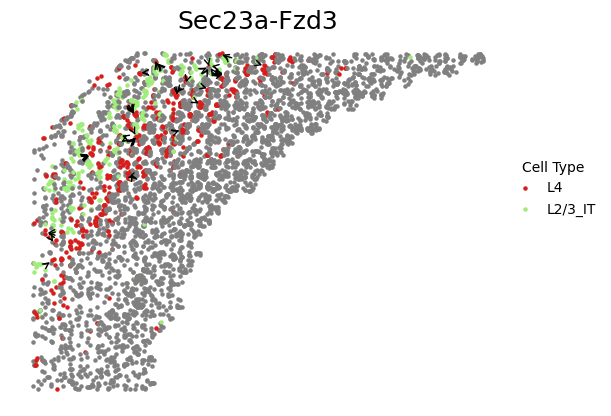

In [181]:
%matplotlib inline
import matplotlib.pyplot as plt

dt.plot_CCC_ST(adata_segment, mapping_colors, cluster, st_data, ligand = 'Sec23a',
    receptor = 'Fzd3',CCC_label = Test_dir + '/data/Sec23a_Fzd3/predict_ccc.txt',
    sourcetype = 'L2/3_IT',targettype = 'L4',top_score = 50)

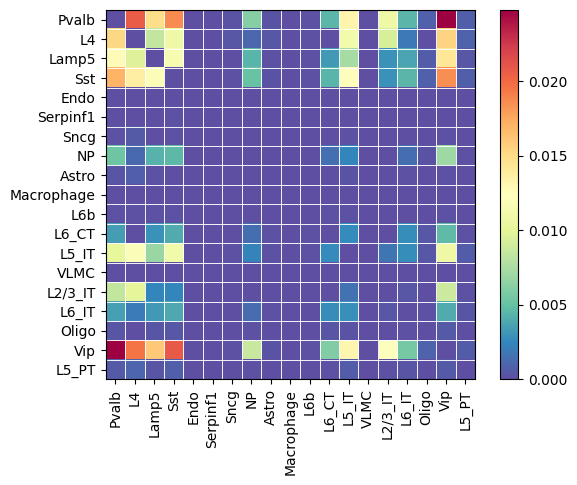

In [182]:
%matplotlib inline
import matplotlib.pyplot as plt
dt.plot_CCC_heatmap(cluster, st_data, ligand = 'Sec23a', receptor = 'Fzd3',
    CCC_label = Test_dir + '/data/Sec23a_Fzd3/predict_ccc.txt')